# **Week 1: Data Cleaning and Preliminary EDA**
----

## 1. Load Required Libraries

In [1]:

if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, naniar, corrplot, psych, moments)


Loading required package: pacman

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘pacman’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘remotes’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’



naniar installed

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


corrplot installed

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘mnormt’, ‘GPArotation’



psych installed

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


moments installed



## 2. Load the Data & Initial Checks

In [4]:
# Install and load palmerpenguins
if (!require("palmerpenguins")) install.packages("palmerpenguins")
library(palmerpenguins)

# Load as a standard data frame
data_raw <- as.data.frame(penguins)

# View dimensions, structure, and missing values
cat("--- Dimensions ---\n")
dim(data_raw)

cat("\n--- Missing Value Count ---\n")
colSums(is.na(data_raw))

str(data_raw)

Loading required package: palmerpenguins

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘palmerpenguins’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw




--- Dimensions ---


[1] 344   8


--- Missing Value Count ---


species            island    bill_length_mm     bill_depth_mm 
                0                 0                 2                 2 
flipper_length_mm       body_mass_g               sex              year 
                2                 2                11                 0

'data.frame':	344 obs. of  8 variables:
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num  39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num  18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int  181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int  3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...
 $ year             : int  2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


## 3. Data Cleaning & Preprocessing

In [9]:
# 1. Inspect and impute missing numerical values using Median
data_clean <- data_raw

for (col in c("bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g")) {
  med_val <- median(data_clean[[col]], na.rm = TRUE)
  data_clean[[col]][is.na(data_clean[[col]])] <- med_val
}

# 2. Impute categorical missing values (Sex)
data_clean$sex <- as.character(data_clean$sex)
data_clean$sex[is.na(data_clean$sex)] <- "Unknown"
data_clean$sex <- as.factor(data_clean$sex)

# 3. Outlier Capping function (IQR Method)
cap_outliers <- function(x) {
  qnt <- quantile(x, probs = c(0.25, 0.75), na.rm = TRUE)
  iqr <- diff(qnt)
  caps <- c(qnt[1] - 1.5 * iqr, qnt[2] + 1.5 * iqr)
  x[x < caps[1]] <- caps[1]
  x[x > caps[2]] <- caps[2]
  return(x)
}

data_clean$body_mass_g <- cap_outliers(data_clean$body_mass_g)
data_clean$flipper_length_mm <- cap_outliers(data_clean$flipper_length_mm)

# 4. Feature Scaling (Z-score standardisation)
data_clean$body_mass_scaled <- as.numeric(scale(data_clean$body_mass_g))

# 5. Output summary
summary(data_clean)

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.27   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
 flipper_length_mm  body_mass_g        sex           year     
 Min.   :172.0     Min.   :2700   female :165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male   :168   1st Qu.:2007  
 Median :197.0     Median :4050   Unknown: 11   Median :2008  
 Mean   :200.9     Mean   :4201                 Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                 3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                 Max.   :2009  
 body_mass_scaled 
 Min.   :-1.8768  
 1st Qu.:-0.8139  
 Median :-0.1887  
 Mean   : 0.0000  
 3rd Qu.:

## 4. Visualizations for Deliverable

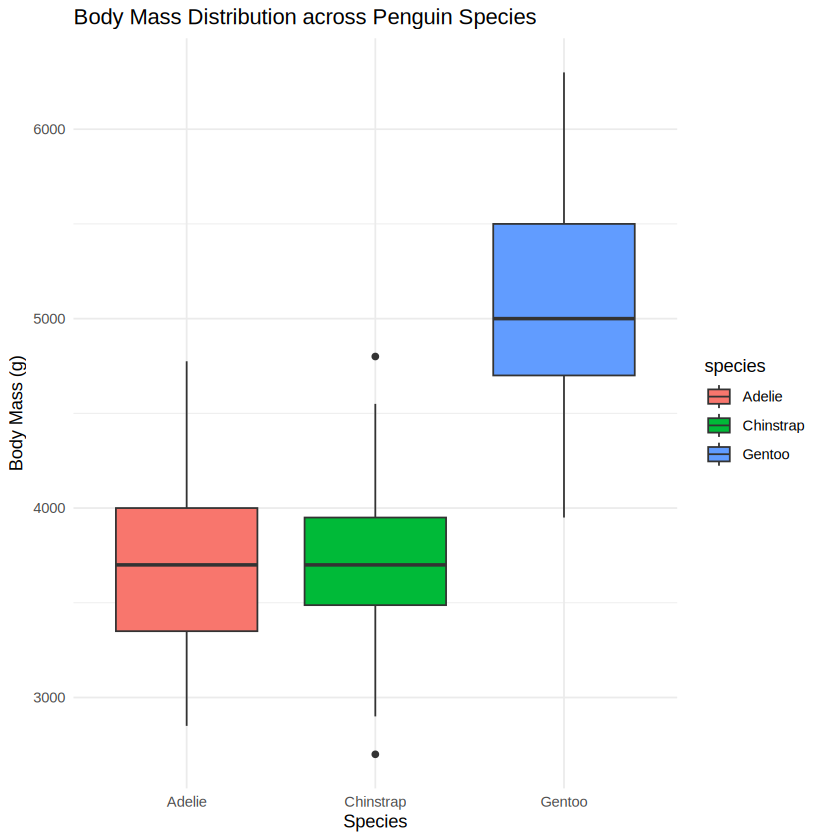

In [6]:
# Plot 1: Boxplot of Body Mass by Species
ggplot(data_clean, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot() +
  labs(title = "Body Mass Distribution across Penguin Species", x = "Species", y = "Body Mass (g)") +
  theme_minimal()

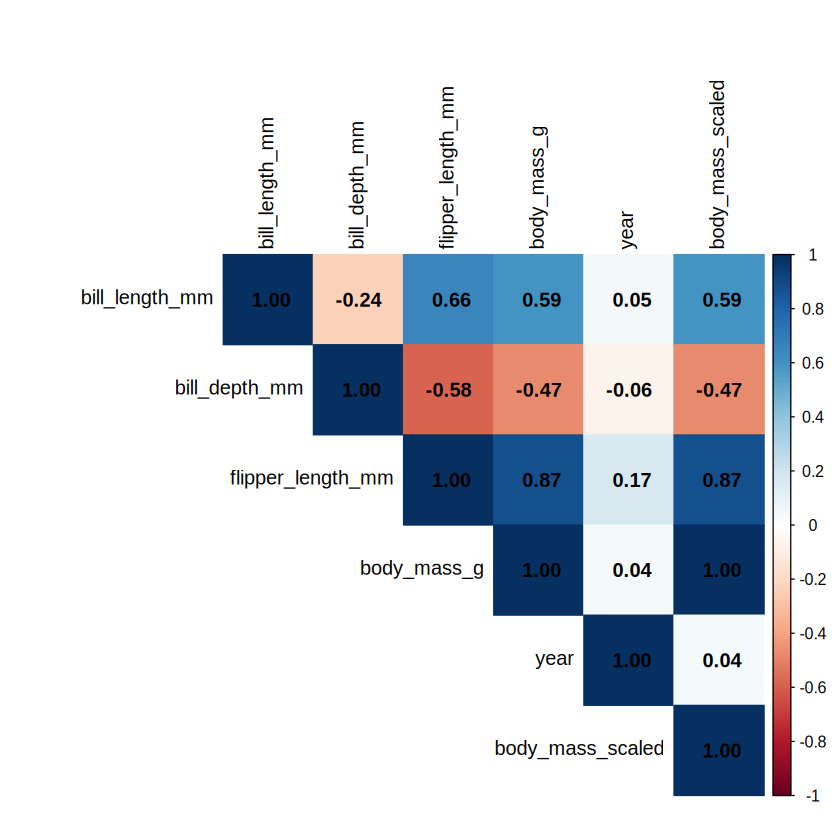

In [7]:
# Plot 2: Correlation Matrix for Numeric Features
num_cols <- data_clean %>% select(where(is.numeric))
corrplot(cor(num_cols), method = "color", type = "upper", addCoef.col = "black", tl.col = "black")

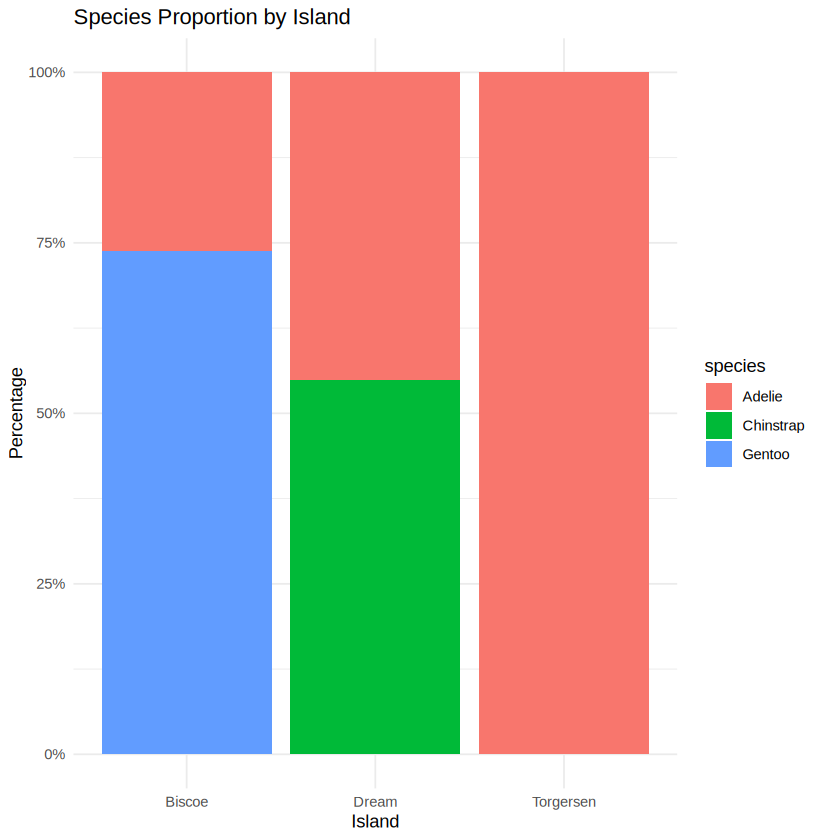

In [8]:
# Plot 3: Categorical Breakdown across Islands
ggplot(data_clean, aes(x = island, fill = species)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  labs(title = "Species Proportion by Island", x = "Island", y = "Percentage") +
  theme_minimal()